# Substitution Ciphers

## Introduction

A substitution cipher is a method of encryption where each letter in the original message (plaintext) is replaced with another letter or symbol. The replacement follows a fixed rule, creating a secret code.

## 1. Caesar Cipher

The Caesar cipher is a classical substitution cipher where each plaintext letter is shifted by a fixed number of positions down the alphabet. For example, with a shift of 3, "A" becomes "D", and "Z" wraps to "C". The Caesar cipher's limited 26 possible shifts make it easy to break with brute-force attacks.

### Encryption

In [1]:
def caesar_encrypt(plaintext, shift):
    ciphertext = []
    for char in plaintext:
        if char.islower():
            encrypted = chr((ord(char) - ord('a') + shift)%26+ord('a'))
            ciphertext.append(encrypted)
        else:
            ciphertext.append(char)
    return '' .join(ciphertext)


In [2]:
# code snippet to test the implementation of the encryption function
plaintext = 'hello!' 
ciphertext = caesar_encrypt(plaintext, shift=4)

print(plaintext, '->', ciphertext) # expected output 'hello! -> lipps!'

hello! -> lipps!


### Decryption

In [3]:
def caesar_decrypt(ciphertext, shift):
    plaintext = [ ]
    for char in ciphertext:
        if char.islower():
            decrypted = chr((ord(char) - ord('a') - shift)%26 + ord('a'))
            plaintext.append(decrypted)
        else:
            plaintext.append(char)
    return '' .join(plaintext)

In [4]:
# code snippet to test the implementation of the decryption function
ciphertext = 'lipps!' # 'hello!' encoded with shift=4
plaintext = caesar_decrypt(ciphertext, shift=4)

print(ciphertext, '->', plaintext)  # expected output 'lipps! -> hello!'

lipps! -> hello!


### Ciphertext

In [5]:
# Load ciphertext
import sys

file_path = 'ciphertext_caesar.txt'

def read_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return  f.read()
        
    except FileNotFoundError:
        print(f"Error: File {file_path} not found")
        sys.exit(1)
    except UnicodeDecodeError:
        print("Error: File encoding not compatible. Try saving the file in UTF-8 or ANSI encoding.")
        sys.exit(1)

ciphertext_caesar = read_file(file_path)

### Brute Force Attack

This program cracks Caesar Cipher by trying every possible shift (1-25). It flips letters backward for each shift, keeps symbols as they are, and prints all results. Just look for the readable text — once found, the cipher is broken!

In [6]:
def brute_force_caesar(ciphertext):
    print("Original ciphertext:")
    print(f"{ciphertext[:100]}...")
    print("Possible decrypted texts for all shifts:")

    for shift in range(1, 26):
        decrypted = caesar_decrypt(ciphertext, shift)
        if len(decrypted) > 100:
            truncated_text = decrypted[:100] + "..."
        else:
            truncated_text = decrypted
        print(f"shift{shift:2d} | {truncated_text}")

brute_force_caesar(ciphertext_caesar)

Original ciphertext:
jgew (alsdasf sfv dslaf: jges, hjgfgmfuwv [ˈjgːes] ) ak lzw ushalsd ualq gx alsdq. al ak sdkg lzw us...
Possible decrypted texts for all shifts:
shift 1 | ifdv (zkrczre reu crkze: ifdr, gifefletvu [ˈifːdr] ) zj kyv trgzkrc tzkp fw zkrcp. zk zj rcjf kyv tr...
shift 2 | hecu (yjqbyqd qdt bqjyd: hecq, fhedekdsut [ˈheːcq] ) yi jxu sqfyjqb syjo ev yjqbo. yj yi qbie jxu sq...
shift 3 | gdbt (xipaxpc pcs apixc: gdbp, egdcdjcrts [ˈgdːbp] ) xh iwt rpexipa rxin du xipan. xi xh pahd iwt rp...
shift 4 | fcas (whozwob obr zohwb: fcao, dfcbcibqsr [ˈfcːao] ) wg hvs qodwhoz qwhm ct whozm. wh wg ozgc hvs qo...
shift 5 | ebzr (vgnyvna naq yngva: ebzn, cebabhaprq [ˈebːzn] ) vf gur pncvgny pvgl bs vgnyl. vg vf nyfb gur pn...
shift 6 | dayq (ufmxumz mzp xmfuz: daym, bdazagzoqp [ˈdaːym] ) ue ftq ombufmx oufk ar ufmxk. uf ue mxea ftq om...
shift 7 | czxp (telwtly lyo wlety: czxl, aczyzfynpo [ˈczːxl] ) td esp nlatelw ntej zq telwj. te td lwdz esp nl...
shift 8 | bywo (sdkvskx kxn vkdsx: b

After testing all shifts, the correct plaintext is found at shift equal to 18. The full decrypted message is shown below:

In [7]:
plaintext_caesar = caesar_decrypt(ciphertext_caesar, shift=18)
print("Decrypted plaintext: ")
print(plaintext_caesar)

Decrypted plaintext: 
rome (italian and latin: roma, pronounced [ˈroːma] ) is the capital city of italy. it is also the capital of the lazio region, the centre of the metropolitan city of rome capital, and a special comune (municipality) named comune di roma capitale. with 2,860,009 residents in 1,285 km2 (496.1 sq mi), rome is the country's most populated comune and the third most populous city in the european union by population within city limits. the metropolitan city of rome, with a population of 4,355,725 residents, is the most populous metropolitan city in italy. its metropolitan area is the third-most populous within italy. rome is located in the central-western portion of the italian peninsula, within lazio (latium), along the shores of the tiber valley. vatican city (the smallest country in the world and headquarters of the worldwide catholic church under the governance of the holy see) is an independent country inside the city boundaries of rome, the only existing example of

## 2: Simple Substitution Cipher

The Simple Substitution Cipher is a type of substitution cipher where each plaintext letter is uniquely replaced by another letter throughout the entire message. Unlike the Caesar Cipher, this cipher allows ​26! possible mappings, making it vastly more complex. But it can be cracked using ​frequency analysis because common letters like "E" leave predictable patterns.

### Encryption

In [8]:
def substitution_encrypt(plaintext, mapping):
    encrypted_chars = []
    for char in plaintext:
        if char in mapping:
            encrypted_char = mapping[char]
        else:
            encrypted_char = char
        encrypted_chars.append(encrypted_char)

    return ''.join(encrypted_chars)

In [9]:
# code snippet to test the implementation of the encryption function
plaintext = 'hello!'
mapping = {'h': 'a', 'e': 'p', 'l': 'w', 'o': 'q'} 

ciphertext = substitution_encrypt(plaintext, mapping)

print(plaintext, '->', ciphertext) # expected output 'hello! -> apwwq!'

hello! -> apwwq!


### Decryption

In [10]:
def substitution_decrypt(ciphertext, mapping):
    decryption_dict = {}
    for plain_char, cipher_char in mapping.items():
        decryption_dict[cipher_char] = plain_char
    
    plaintext = []
    for char in ciphertext:

        if char in decryption_dict:
            plaintext.append(decryption_dict[char])
        else:
            plaintext.append(char)

    return ''.join(plaintext)

In [11]:
# code snippet to test the implementation of the decryption function
mapping = {'h': 'a', 'e': 'p', 'l': 'w', 'o': 'q'}  # previous mapping 
ciphertext = 'apwwq!'

plaintext = substitution_decrypt(ciphertext, mapping)

print(ciphertext, '->', plaintext)  # expected output 'apwwq! -> hello!'

apwwq! -> hello!


### Ciphertext

In [12]:
# Load ciphertext
import sys

ciphertext_path = 'ciphertext_simple.txt'

"""
def read_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        print(f"Error: File {file_path} not found")
        sys.exit(1)
    except UnicodeDecodeError:
        print("Error: File encoding not compatible. Try saving the file in UTF-8 or ANSI encoding.")
        sys.exit(1)
"""

ciphertext_simple = read_file(ciphertext_path)

### Frequency Analysis Attack

This program analyzes letter frequency distribution in an English text and sorts it, then calculates ciphertext letter frequencies and sorts them identically. Aligning both sorted lists generates a mapping to initially decrypt the ciphertext, with manual adjustments applied to refine the mapping.

#### English Letters Distribution

In [13]:
import string

def letter_distribution(text):
    counts = {char: 0 for char in string.ascii_lowercase}

    for char in text:
        if char in counts:
            counts[char] += 1

    total = max(1, sum(counts.values()))
    return {char: count/total for char, count in counts.items() }


In [14]:
# code snippet to test the implementation of `letter_distribution`
text = 'hello world!'

letter_distribution(text)
# expected ouput: 
# {'d': 0.1, 'e': 0.1, 'h': 0.1, 'l': 0.3, 'o': 0.2, 'r': 0.1, 'w': 0.1, ...}

{'a': 0.0,
 'b': 0.0,
 'c': 0.0,
 'd': 0.1,
 'e': 0.1,
 'f': 0.0,
 'g': 0.0,
 'h': 0.1,
 'i': 0.0,
 'j': 0.0,
 'k': 0.0,
 'l': 0.3,
 'm': 0.0,
 'n': 0.0,
 'o': 0.2,
 'p': 0.0,
 'q': 0.0,
 'r': 0.1,
 's': 0.0,
 't': 0.0,
 'u': 0.0,
 'v': 0.0,
 'w': 0.1,
 'x': 0.0,
 'y': 0.0,
 'z': 0.0}

In [15]:
# load text
text_path = 'wikipedia_cybersecurity.txt'
english_text = read_file(text_path)

In [16]:
# estimate the English letters distribution 
English_letters_distribution = letter_distribution(english_text)
print(English_letters_distribution)

{'a': 0.08323779835894529, 'b': 0.013692630711166644, 'c': 0.047415403243466055, 'd': 0.0345600453415429, 'e': 0.12422552265144977, 'f': 0.0197467571780042, 'g': 0.01835559620264578, 'h': 0.03197094019295918, 'i': 0.07686164388855254, 'j': 0.000566769286257133, 'k': 0.00835984697229271, 'l': 0.03564205943348834, 'm': 0.026084268287970322, 'n': 0.07423389537954221, 'o': 0.07273968544304613, 'p': 0.021988072082748316, 'q': 0.0006311748869681708, 'r': 0.07064006285986629, 's': 0.07326781136887664, 't': 0.09289863846560097, 'u': 0.027333736941764455, 'v': 0.01148995916684915, 'w': 0.011180812283436167, 'x': 0.0015972588976337382, 'y': 0.019785400538430822, 'z': 0.0014942099364960778}


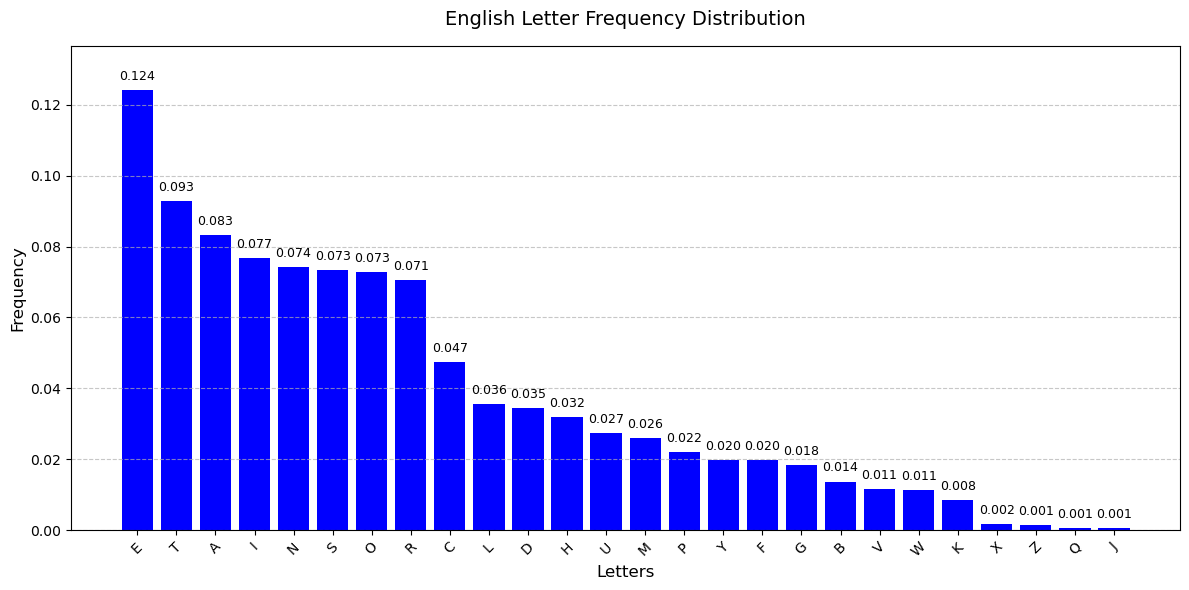

In [17]:
# plot the English letter distribution
import matplotlib.pyplot as plt
from operator import itemgetter

def plot_English_letter_distribution(distribution, title='English Letter Frequency Distribution'):
    # Plot English letter frequency distribution in descending order
    plt.figure(figsize=(12, 6))
    
    # Sort letters by frequency descending
    sorted_items = sorted(distribution.items(), key=itemgetter(1), reverse=True)
    letters = [item[0].upper() for item in sorted_items]
    frequencies = [item[1] for item in sorted_items]
    
    # Create bar plot
    bars = plt.bar(range(len(letters)), frequencies, color='blue')
    
    # Configure plot
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Letters', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xticks(range(len(letters)), letters, rotation=45, fontsize=10)
    plt.ylim(0, max(frequencies) * 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                height + 0.002,
                f'{height:.3f}',
                ha='center',
                va='bottom',
                fontsize=9)

    plt.tight_layout()
    plt.show()

plot_English_letter_distribution(English_letters_distribution)

In [18]:
# store the distribution as a pickle file
import pickle

def save_distribution_to_pickle(distribution, file_path='distribution.pkl'):
    with open(file_path, 'wb') as f:
        pickle.dump(distribution, f, protocol=pickle.HIGHEST_PROTOCOL)

save_distribution_to_pickle(English_letters_distribution)

#### Perform attack

In [19]:
# perform Frequency analysis attack

# Converts letter frequency distribution into sorted lists for matching.
def sort_distribution(english_dist):
    sorted_letters = sorted(english_dist.items(), key=lambda item: (-item[1], item[0])) 
    return [item[0] for item in sorted_letters]

ciphertext_letters_distribution = letter_distribution(ciphertext_simple)
ciphertext_letters_order = sort_distribution(ciphertext_letters_distribution)
English_letters_order = sort_distribution(English_letters_distribution)

print("Cipher  letters frequency order:", ciphertext_letters_order)
print("English letters frequency order:", English_letters_order)

def frequency_based_substitution(text, cipher_order, english_order):
    # Create substitution mapping
    mapping = {}  # Dictionary to store list correspondence
    for cipher_char, english_char in zip(cipher_order, english_order):
        # Store original list correspondence
        mapping[cipher_char] = english_char
        
    # Perform character substitution
    transformed_chars = []
    for char in text:
        # Preserve non-alphabetic characters
        transformed_chars.append(mapping.get(char, char))
    
    return ''.join(transformed_chars), mapping

decrypted_text, mapping = frequency_based_substitution(ciphertext_simple, ciphertext_letters_order, English_letters_order)


Cipher  letters frequency order: ['m', 'g', 'b', 'v', 'l', 'f', 's', 'd', 'c', 'w', 'p', 'j', 'y', 'x', 'k', 'o', 'r', 'e', 't', 'u', 'a', 'q', 'n', 'h', 'i', 'z']
English letters frequency order: ['e', 't', 'a', 'i', 'n', 's', 'o', 'r', 'c', 'l', 'd', 'h', 'u', 'm', 'p', 'y', 'f', 'g', 'b', 'v', 'w', 'k', 'x', 'z', 'q', 'j']


In [20]:
# print mapping
print("Mapping:", mapping)

Mapping: {'m': 'e', 'g': 't', 'b': 'a', 'v': 'i', 'l': 'n', 'f': 's', 's': 'o', 'd': 'r', 'c': 'c', 'w': 'l', 'p': 'd', 'j': 'h', 'y': 'u', 'x': 'm', 'k': 'p', 'o': 'y', 'r': 'f', 'e': 'g', 't': 'b', 'u': 'v', 'a': 'w', 'q': 'k', 'n': 'x', 'h': 'z', 'i': 'q', 'z': 'j'}


In [21]:
# print decrypted plaintext
print(decrypted_text)

is dogutrboaucg, a nmyntitmtirs diuceo in a petcrh rf esdogutisb is vcidc msitn rf ulaistext aoe oeuladeh vitc tce diuceotext, is a hefiseh passeo, vitc tce celu rf a keg; tce "msitn" pag ye nisble letteon (tce prnt drpprs), uaion rf letteon, toiuletn rf letteon, pixtmoen rf tce ayrwe, ash nr frotc. tce oedeiweo hediuceon tce text yg ueofropisb tce isweone nmyntitmtirs uordenn tr extoadt tce roibisal pennabe.
nmyntitmtirs diuceon das ye drpuaoeh vitc toasnurnitirs diuceon. is a toasnurnitirs diuceo, tce msitn rf tce ulaistext aoe oeaooasbeh is a hiffeoest ash mnmallg zmite drpulex roheo, ymt tce msitn tcepnelwen aoe left msdcasbeh. yg drstoant, is a nmyntitmtirs diuceo, tce msitn rf tce ulaistext aoe oetaiseh is tce nape nezmesde is tce diuceotext, ymt tce msitn tcepnelwen aoe alteoeh.
tceoe aoe a smpyeo rf hiffeoest tguen rf nmyntitmtirs diuceo. if tce diuceo rueoaten rs nisble letteon, it in teopeh a nipule nmyntitmtirs diuceo; a diuceo tcat rueoaten rs laobeo bormun rf letteon in te

### Manually adjusting the letter mappings

From the decrypted text above, we observe that the result is not entirely accurate. However, certain patterns provide valuable clues. 

For instance, the sequence "aoe" might correspond to the word "are." Based on such insights, we further refined the decryption by manually adjusting the letter mappings. 

To maintain consistency and avoid confusion, we ensured that each adjustment involved changing two mappings simultaneously, preserving the bijective relationship between the ciphertext and plaintext letter sets. 

In [22]:
decrypted_text, mapping = frequency_based_substitution(ciphertext_simple, ciphertext_letters_order, English_letters_order)
mapping['s'] = 'r'
mapping['d'] = 'o'
decrypted_text = ''.join(mapping.get(char, char) for char in ciphertext_simple)
print("mapping:", mapping)

mapping: {'m': 'e', 'g': 't', 'b': 'a', 'v': 'i', 'l': 'n', 'f': 's', 's': 'r', 'd': 'o', 'c': 'c', 'w': 'l', 'p': 'd', 'j': 'h', 'y': 'u', 'x': 'm', 'k': 'p', 'o': 'y', 'r': 'f', 'e': 'g', 't': 'b', 'u': 'v', 'a': 'w', 'q': 'k', 'n': 'x', 'h': 'z', 'i': 'q', 'z': 'j'}


In [23]:
# print decrypted plaintext
print(decrypted_text)

is drgutobraucg, a nmyntitmtios diucer in a petcoh of esdrgutisb is vcidc msitn of ulaistext are reuladeh vitc tce diucertext, is a hefiseh passer, vitc tce celu of a keg; tce "msitn" pag ye nisble lettern (tce pont doppos), uairn of lettern, triuletn of lettern, pixtmren of tce ayowe, ash no fortc. tce redeiwer hediucern tce text yg uerforpisb tce iswerne nmyntitmtios urodenn to extradt tce oribisal pennabe.
nmyntitmtios diucern das ye dopuareh vitc trasnuonitios diucern. is a trasnuonitios diucer, tce msitn of tce ulaistext are rearrasbeh is a hifferest ash mnmallg zmite dopulex orher, ymt tce msitn tcepnelwen are left msdcasbeh. yg dostrant, is a nmyntitmtios diucer, tce msitn of tce ulaistext are retaiseh is tce nape nezmesde is tce diucertext, ymt tce msitn tcepnelwen are altereh.
tcere are a smpyer of hifferest tguen of nmyntitmtios diucer. if tce diucer oueraten os nisble lettern, it in terpeh a nipule nmyntitmtios diucer; a diucer tcat oueraten os larber bromun of lettern in te

The decrypted text has improved, and we can now identify additional patterns. For example, the sequence "tce" might correspond to the word "the."

In [24]:
decrypted_text, mapping = frequency_based_substitution(ciphertext_simple, ciphertext_letters_order, English_letters_order)
mapping['s'] = 'r'
mapping['d'] = 'o'

mapping['c'] = 'h'
mapping['j'] = 'c'

decrypted_text = ''.join(mapping.get(char, char) for char in ciphertext_simple)
print("mapping:", mapping)

mapping: {'m': 'e', 'g': 't', 'b': 'a', 'v': 'i', 'l': 'n', 'f': 's', 's': 'r', 'd': 'o', 'c': 'h', 'w': 'l', 'p': 'd', 'j': 'c', 'y': 'u', 'x': 'm', 'k': 'p', 'o': 'y', 'r': 'f', 'e': 'g', 't': 'b', 'u': 'v', 'a': 'w', 'q': 'k', 'n': 'x', 'h': 'z', 'i': 'q', 'z': 'j'}


In [25]:
# print decrypted plaintext
print(decrypted_text)

is drgutobrauhg, a nmyntitmtios diuher in a pethoc of esdrgutisb is vhidh msitn of ulaistext are reuladec vith the diuhertext, is a cefisec passer, vith the helu of a keg; the "msitn" pag ye nisble lettern (the pont doppos), uairn of lettern, triuletn of lettern, pixtmren of the ayowe, asc no forth. the redeiwer cediuhern the text yg uerforpisb the iswerne nmyntitmtios urodenn to extradt the oribisal pennabe.
nmyntitmtios diuhern das ye dopuarec vith trasnuonitios diuhern. is a trasnuonitios diuher, the msitn of the ulaistext are rearrasbec is a cifferest asc mnmallg zmite dopulex orcer, ymt the msitn thepnelwen are left msdhasbec. yg dostrant, is a nmyntitmtios diuher, the msitn of the ulaistext are retaisec is the nape nezmesde is the diuhertext, ymt the msitn thepnelwen are alterec.
there are a smpyer of cifferest tguen of nmyntitmtios diuher. if the diuher oueraten os nisble lettern, it in terpec a nipule nmyntitmtios diuher; a diuher that oueraten os larber bromun of lettern in te

The sequence "hov" might correspond to the word "how," and "ve" could represent "we."

In [26]:
decrypted_text, mapping = frequency_based_substitution(ciphertext_simple, ciphertext_letters_order, English_letters_order)

mapping['s'] = 'r'
mapping['d'] = 'o'
mapping['c'] = 'h'
mapping['j'] = 'd'

mapping['u'] = 'w'
mapping['a'] = 'v'


decrypted_text = ''.join(mapping.get(char, char) for char in ciphertext_simple)
print("mapping:", mapping)

mapping: {'m': 'e', 'g': 't', 'b': 'a', 'v': 'i', 'l': 'n', 'f': 's', 's': 'r', 'd': 'o', 'c': 'h', 'w': 'l', 'p': 'd', 'j': 'd', 'y': 'u', 'x': 'm', 'k': 'p', 'o': 'y', 'r': 'f', 'e': 'g', 't': 'b', 'u': 'w', 'a': 'v', 'q': 'k', 'n': 'x', 'h': 'z', 'i': 'q', 'z': 'j'}


In [27]:
# print decrypted plaintext
print(decrypted_text)

is drgutobrauhg, a nmyntitmtios diuher in a pethod of esdrgutisb is whidh msitn of ulaistext are reuladed with the diuhertext, is a defised passer, with the helu of a keg; the "msitn" pag ye nisble lettern (the pont doppos), uairn of lettern, triuletn of lettern, pixtmren of the ayove, asd no forth. the redeiver dediuhern the text yg uerforpisb the isverne nmyntitmtios urodenn to extradt the oribisal pennabe.
nmyntitmtios diuhern das ye dopuared with trasnuonitios diuhern. is a trasnuonitios diuher, the msitn of the ulaistext are rearrasbed is a differest asd mnmallg zmite dopulex order, ymt the msitn thepnelven are left msdhasbed. yg dostrant, is a nmyntitmtios diuher, the msitn of the ulaistext are retaised is the nape nezmesde is the diuhertext, ymt the msitn thepnelven are altered.
there are a smpyer of differest tguen of nmyntitmtios diuher. if the diuher oueraten os nisble lettern, it in terped a nipule nmyntitmtios diuher; a diuher that oueraten os larber bromun of lettern in te

In the analysis, we identified that the term "diuhertext" might be a misinterpretation and could potentially represent the word "ciphertext."

In [28]:
decrypted_text, mapping = frequency_based_substitution(ciphertext_simple, ciphertext_letters_order, English_letters_order)

mapping['s'] = 'r'
mapping['d'] = 'o'
mapping['c'] = 'h'
mapping['j'] = 'd'
mapping['u'] = 'w'
mapping['a'] = 'v'

mapping['p'] = 'c'
mapping['j'] = 'd'
mapping['y'] = 'p'
mapping['k'] = 'u'

decrypted_text = ''.join(mapping.get(char, char) for char in ciphertext_simple)
print("mapping:", mapping)

mapping: {'m': 'e', 'g': 't', 'b': 'a', 'v': 'i', 'l': 'n', 'f': 's', 's': 'r', 'd': 'o', 'c': 'h', 'w': 'l', 'p': 'c', 'j': 'd', 'y': 'p', 'x': 'm', 'k': 'u', 'o': 'y', 'r': 'f', 'e': 'g', 't': 'b', 'u': 'w', 'a': 'v', 'q': 'k', 'n': 'x', 'h': 'z', 'i': 'q', 'z': 'j'}


In [29]:
# print decrypted plaintext
print(decrypted_text)

is crgptobraphg, a nmyntitmtios cipher in a uethod of escrgptisb is which msitn of plaistext are replaced with the ciphertext, is a defised uasser, with the help of a keg; the "msitn" uag ye nisble lettern (the uont couuos), pairn of lettern, tripletn of lettern, uixtmren of the ayove, asd no forth. the receiver deciphern the text yg perforuisb the isverne nmyntitmtios procenn to extract the oribisal uennabe.
nmyntitmtios ciphern cas ye coupared with trasnponitios ciphern. is a trasnponitios cipher, the msitn of the plaistext are rearrasbed is a differest asd mnmallg zmite couplex order, ymt the msitn theunelven are left mschasbed. yg costrant, is a nmyntitmtios cipher, the msitn of the plaistext are retaised is the naue nezmesce is the ciphertext, ymt the msitn theunelven are altered.
there are a smuyer of differest tgpen of nmyntitmtios cipher. if the cipher operaten os nisble lettern, it in terued a niuple nmyntitmtios cipher; a cipher that operaten os larber brompn of lettern in te

The term "uethod" likely corresponds to the word "method," and "defised" might represent "defined." These observations allowed us to refine the letter mappings further, enhancing the accuracy of the decryption process.

In [30]:
decrypted_text, mapping = frequency_based_substitution(ciphertext_simple, ciphertext_letters_order, English_letters_order)

mapping['s'] = 'r'
mapping['d'] = 'o'
mapping['c'] = 'h'
mapping['j'] = 'd'
mapping['u'] = 'w'
mapping['a'] = 'v'
mapping['p'] = 'c'
mapping['j'] = 'd'
mapping['y'] = 'p'
mapping['k'] = 'u'

mapping['x'] = 'u'
mapping['k'] = 'm'

mapping['l'] = 's'
mapping['f'] = 'n'

decrypted_text = ''.join(mapping.get(char, char) for char in ciphertext_simple)
print("mapping:", mapping)

mapping: {'m': 'e', 'g': 't', 'b': 'a', 'v': 'i', 'l': 's', 'f': 'n', 's': 'r', 'd': 'o', 'c': 'h', 'w': 'l', 'p': 'c', 'j': 'd', 'y': 'p', 'x': 'u', 'k': 'm', 'o': 'y', 'r': 'f', 'e': 'g', 't': 'b', 'u': 'w', 'a': 'v', 'q': 'k', 'n': 'x', 'h': 'z', 'i': 'q', 'z': 'j'}


In [31]:
# print decrypted plaintext
print(decrypted_text)

in crgptobraphg, a suystitution cipher is a method of encrgptinb in which units of plaintext are replaced with the ciphertext, in a defined manner, with the help of a keg; the "units" mag ye sinble letters (the most common), pairs of letters, triplets of letters, mixtures of the ayove, and so forth. the receiver deciphers the text yg performinb the inverse suystitution process to extract the oribinal messabe.
suystitution ciphers can ye compared with transposition ciphers. in a transposition cipher, the units of the plaintext are rearranbed in a different and usuallg zuite complex order, yut the units themselves are left unchanbed. yg contrast, in a suystitution cipher, the units of the plaintext are retained in the same sezuence in the ciphertext, yut the units themselves are altered.
there are a numyer of different tgpes of suystitution cipher. if the cipher operates on sinble letters, it is termed a simple suystitution cipher; a cipher that operates on larber broups of letters is te

The term "ye" likely corresponds to the word "be," and "tgpes" might represent "types." These observations allowed us to refine the letter mappings and improve the accuracy of the decrypted text. By systematically analyzing and correcting such patterns, we were able to reconstruct the original plaintext successfully.

In [32]:
decrypted_text, mapping = frequency_based_substitution(ciphertext_simple, ciphertext_letters_order, English_letters_order)

mapping['s'] = 'r'
mapping['d'] = 'o'
mapping['c'] = 'h'
mapping['j'] = 'd'
mapping['u'] = 'w'
mapping['a'] = 'v'
mapping['p'] = 'c'
mapping['j'] = 'd'
mapping['y'] = 'p'
mapping['k'] = 'u'
mapping['x'] = 'u'
mapping['k'] = 'm'
mapping['l'] = 's'
mapping['f'] = 'n'

mapping['o'] = 'b'
mapping['t'] = 'y'

mapping['e'] = 'y'
mapping['t'] = 'g'

decrypted_text = ''.join(mapping.get(char, char) for char in ciphertext_simple)
print("mapping:", mapping)

mapping: {'m': 'e', 'g': 't', 'b': 'a', 'v': 'i', 'l': 's', 'f': 'n', 's': 'r', 'd': 'o', 'c': 'h', 'w': 'l', 'p': 'c', 'j': 'd', 'y': 'p', 'x': 'u', 'k': 'm', 'o': 'b', 'r': 'f', 'e': 'y', 't': 'g', 'u': 'w', 'a': 'v', 'q': 'k', 'n': 'x', 'h': 'z', 'i': 'q', 'z': 'j'}


In [33]:
# print decrypted plaintext
print(decrypted_text)

in cryptography, a substitution cipher is a method of encrypting in which units of plaintext are replaced with the ciphertext, in a defined manner, with the help of a key; the "units" may be single letters (the most common), pairs of letters, triplets of letters, mixtures of the above, and so forth. the receiver deciphers the text by performing the inverse substitution process to extract the original message.
substitution ciphers can be compared with transposition ciphers. in a transposition cipher, the units of the plaintext are rearranged in a different and usually zuite complex order, but the units themselves are left unchanged. by contrast, in a substitution cipher, the units of the plaintext are retained in the same sezuence in the ciphertext, but the units themselves are altered.
there are a number of different types of substitution cipher. if the cipher operates on single letters, it is termed a simple substitution cipher; a cipher that operates on larger groups of letters is te

## Bonus Task: Affine Cipher

The Affine Cipher is a type of monoalphabetic substitution cipher and inherits its weaknesses. In English (with 26 letters), there are 286 non-trivial affine ciphers, as there are 12 numbers less than 26 that are coprime with 26, each offering 26 possible shifts. This limited key space makes the system insecure according to Kerckhoffs' Principle.

The Caesar Cipher is a specific case of the Affine Cipher with a=1.

### Encryption

In [34]:
from math import gcd

In [35]:
def affine_encrypt(plaintext, a, b):
    ciphertext = ""

    if gcd(a, len(string.ascii_lowercase)) != 1:
        raise ValueError("a must be coprime with 26")
    
    for x in plaintext:
        if x.isalpha():
            new_char = chr((((ord(x.lower()) - 97) * a + b) % 26) + 97)
            
            if x.isupper():
                new_char = new_char.upper()
            ciphertext += new_char
        else:
            ciphertext += x
    return ciphertext

In [36]:
plaintext = 'hello world!'
a, b = 3, 1

ciphertext = affine_encrypt(plaintext, a, b)
print(plaintext, '->', ciphertext) 
# expected output 'hello world! -> wniir praik!'

hello world! -> wniir praik!


### Decryption

In [37]:
def affine_decrypt(ciphertext, a, b):
    ''' Decrypt `ciphertext` (str) as an affine cipher with given `a` and `b`
    '''
    ainv = next((x for x in range(1, 26) if (a * x) % 26 == 1),None)
    if ainv is None:
        raise ValueError("a has no inverse modulo 26")
    
    plaintext = ""
    for x in ciphertext:
      if (x.isalpha()):
          # Apply lower() to the individual character 'x' instead of the list
          new_char = chr((ainv*((ord(x.lower()) - 97) - b) % 26) + 97)
          if x.isupper():
              new_char = new_char.upper()
          plaintext += new_char # Add the new character to the ciphertext
      else:
          plaintext += x

    return plaintext

In [38]:
ciphertext = 'wniir praik!'
a, b = 3, 1

plaintext = affine_decrypt(ciphertext, a, b)
print(ciphertext, '->', plaintext) 
# expected output 'wniir praik! -> hello world!'

wniir praik! -> hello world!


### Ciphertext

In [39]:
# Load ciphertext
import sys

ciphertext_path = 'ciphertext_affine.txt'

def read_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        print(f"Error: File {file_path} not found")
        sys.exit(1)
    except UnicodeDecodeError:
        print("Error: File encoding not compatible. Try saving the file in UTF-8 or ANSI encoding.")
        sys.exit(1)

content = read_file(ciphertext_path)

### Breaking Cipher

#### Method 1: Brute force attack

We employed a brute-force attack to break the cipher since the keys were unknown. While frequency analysis of the alphabet could have been used as an alternative approach, we opted to let the computational loops perform the task through exhaustive search. This method ensured that all possible key combinations were systematically tested, ultimately leading to the successful decryption of the ciphertext.

In [40]:
import itertools

def mod_inverse(a, m):
    '''Find the modular inverse of a modulo m'''
    return next((x for x in range(1, m) if (a * x) % m == 1), None)

def brute_force_affine_decrypt(ciphertext):
    possible_a_values = [a for a in range(1, 26) if mod_inverse(a, 26) is not None]

    for a, b in itertools.product(possible_a_values, range(26)):
        try:
            decrypted_text = affine_decrypt(ciphertext, a, b)
            print(f"a={a}, b={b}: {decrypted_text[:100]}")
        except ValueError:
            continue

ciphertext = content
brute_force_affine_decrypt(ciphertext)

a=1, b=0: yir doofqr xfkire fb d yjkr no tnqndwkidaryfx bvabyfyvyfnq xfkire, pirer rdxi wryyre fq dq dwkidary 
a=1, b=1: xhq cnnepq wejhqd ea c xijq mn smpmcvjhczqxew auzaxexuxemp wejhqd, ohqdq qcwh vqxxqd ep cp cvjhczqx 
a=1, b=2: wgp bmmdop vdigpc dz b whip lm rlolbuigbypwdv ztyzwdwtwdlo vdigpc, ngpcp pbvg upwwpc do bo buigbypw 
a=1, b=3: vfo allcno uchfob cy a vgho kl qknkathfaxovcu ysxyvcvsvckn uchfob, mfobo oauf tovvob cn an athfaxov 
a=1, b=4: uen zkkbmn tbgena bx z ufgn jk pjmjzsgezwnubt xrwxuburubjm tbgena, lenan nzte snuuna bm zm zsgezwnu 
a=1, b=5: tdm yjjalm safdmz aw y tefm ij oiliyrfdyvmtas wqvwtatqtail safdmz, kdmzm mysd rmttmz al yl yrfdyvmt 
a=1, b=6: scl xiizkl rzecly zv x sdel hi nhkhxqecxulszr vpuvszspszhk rzecly, jclyl lxrc qlssly zk xk xqecxuls 
a=1, b=7: rbk whhyjk qydbkx yu w rcdk gh mgjgwpdbwtkryq uoturyrorygj qydbkx, ibkxk kwqb pkrrkx yj wj wpdbwtkr 
a=1, b=8: qaj vggxij pxcajw xt v qbcj fg lfifvocavsjqxp tnstqxqnqxfi pxcajw, hajwj jvpa ojqqjw xi vi vocavsjq 
a

In [41]:
ciphertext = content
a, b = 23, 3

plaintext = affine_decrypt(ciphertext, a, b)
print(plaintext[:800]) # expected output

the affine cipher is a type of monoalphabetic substitution cipher, where each letter in an alphabet is mapped to its numeric equivalent, encrypted using a simple mathematical function, and converted back to a letter. the formula used means that each letter encrypts to one other letter, and back again, meaning the cipher is essentially a standard substitution cipher with a rule governing which letter goes to which. as such, it has the weaknesses of all substitution ciphers. each letter is enciphered with the function (ax + b) mod 26, where b is the magnitude of the shift.


== description ==
here, the letters of an alphabet of size m are first mapped to the integers in the range 0 ... m  1. it then uses modular arithmetic to transform the integer that each plaintext letter corresponds to in


#### Method 2: Frequency attack

Brute force alone is not sufficient. After obtaining all possible decryption results, we still need to identify **which one corresponds to the correct plaintext**.

The following code generates all valid key pairs (a,b). Each candidate key can then be used to decrypt the ciphertext.

To identify the most likely plaintext, we apply **frequency analysis**. The letter-frequency distribution of a correct English plaintext should be close to the known frequency distribution of the English language.

In [42]:
# get all possible values of the (a, b) pairs
m = len(English_letters_distribution) # number of letters in the alphabet
a_list = [a for a in range(m) if gcd(a, m) == 1] # only a coprime with m
b_list = list(range(m))  # any possible integer from 0 to m-1
key_list = list(itertools.product(a_list, b_list))  # all possible pairs (a, b)

print(f'number of pairs (a, b): {len(key_list)}')

number of pairs (a, b): 312


After decrypting the ciphertext , we compare its letter-frequency distribution with the standard English letter distribution.

Let

- $P_i$ be the probability of letter $i$ in a candidate plaintext. It corresponds to `x_values[i]`, where `x` is the letter distribution of the candidate decrypted plaintext;
- $Q_i$ be the reference probability of the same letter in English. It corresponds to `y_values[i]`, where `y` is the standard English letter distribution.

We measure the difference between the two distributions using the Euclidean, or $\ell_2$, distance:

$$

d(P,Q)

=

\sqrt{

\sum_{i=1}^{26}

(P_i-Q_i)^2

}

$$

In [43]:
import numpy as np
def compute_distance(x, y):
    '''Compute the distance (float) between two distribution `a` (dict) and
    `b` (dict) as the norm l2 of the difference between the letters
    probability'''
    x_values = np.array(list(x.values()))
    y_values = np.array(list(y.values()))
    distance = np.sqrt(np.sum((y_values - x_values)**2))
    return distance

In [44]:
# compute the distance for each possible (a, b) pair
distances = np.zeros(len(key_list), dtype=float)
for i, key in enumerate(key_list):
    plaintext = affine_decrypt(ciphertext, *key)
    distribution = letter_distribution(plaintext)
    distances[i] = compute_distance(distribution, English_letters_distribution)

The histogram shows most candidate decryptions have distances between approximately $0.20$ and $0.28$, indicating that their letter-frequency distributions are not close to standard English.

However, one candidate produces a much smaller distance of approximately $0.05$. Therefore, the key associated with the minimum distance is the most likely correct key.

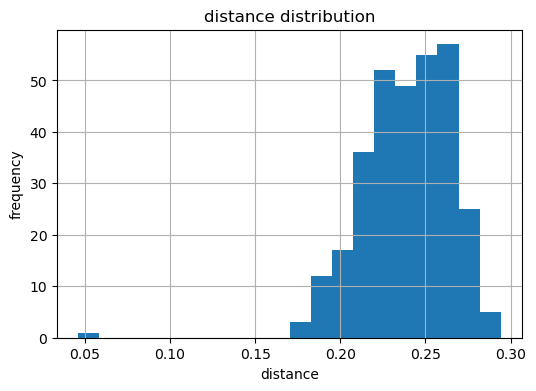

In [45]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(distances, bins=20)
ax.set(xlabel='distance', ylabel='frequency', title='distance distribution')
ax.grid()

In [46]:
key = key_list[np.argmin(distances)]
print(f'a: {key[0]}, b: {key[1]}')

a: 23, b: 3


In [47]:
plaintext = affine_decrypt(ciphertext, *key)
print(plaintext[:800])

the affine cipher is a type of monoalphabetic substitution cipher, where each letter in an alphabet is mapped to its numeric equivalent, encrypted using a simple mathematical function, and converted back to a letter. the formula used means that each letter encrypts to one other letter, and back again, meaning the cipher is essentially a standard substitution cipher with a rule governing which letter goes to which. as such, it has the weaknesses of all substitution ciphers. each letter is enciphered with the function (ax + b) mod 26, where b is the magnitude of the shift.


== description ==
here, the letters of an alphabet of size m are first mapped to the integers in the range 0 ... m  1. it then uses modular arithmetic to transform the integer that each plaintext letter corresponds to in


## Conclusion

This assignment was divided into three parts: the Caesar Cipher, the Simple Substitution Cipher, and the Affine Cipher. Below is a concise summary of the workflow for each part.

All methods are straightforward and easy to understand, but they offer limited security.  This experience has laid foundation for exploring more complex modern encryption techniques. 

Finally, we would like to express our gratitude to Professor Alex Maechioni and Professor Lorenzo Capelli for their insightful lectures and patient guidance, which greatly enhanced our understanding of the subject matter.

### For the Caesar Cipher

We first programmed the encryption code and tested it using the plaintext "hello!" to obtain the ciphertext "lipps!", which confirmed the correctness of the implementation.

Subsequently, we programmed the decryption code and successfully decrypted the ciphertext back to "hello!".

Given the limited key space (only 25 possible keys), we employed a brute-force attack to decrypt a given ciphertext. Among the 26 possible results, the 18th result was identified as the correct plaintext.

### For the Simple Substitution Cipher

We initially programmed the encryption code and verified its accuracy by encrypting "hello!" to produce "apwwq!". 

We then developed the decryption code, which successfully restored the original plaintext "hello!". 

This method has a significantly larger key space (26! possibilities)，a brute-force attack is impractical. Instead, we employed frequency analusis and known plaintext attacks to decrypt a given ciphertext. By analyzing letter frequencies and comparing them to the expected distribution in English, we identified the correct plaintext as the most linguistically plausible result.

### For the Affine Cipher

We initially implemented the encryption code for the Affine Cipher and tested it with the plaintext "hello!" using the keys a=3 and b=1. The resulting ciphertext was "wniir!", which verified the accuracy of our implementation.

Next, we developed the decryption code and successfully decrypted the ciphertext "wniir!" back to "hello!" using the inverse key a=3 and b=1.

Due to the limited key space (only 312 possible keys, as a must be coprime with 26 and b can range from 0 to 25), we utilized a brute-force attack to decrypt a given ciphertext. Among the possible outcomes, the correct plaintext was identified using keys a=23 and b=3.